In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from astropy.io import fits
import csv
from scipy.integrate import quad
import scipy.interpolate as interp
from scipy.optimize import curve_fit

from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import astropy.constants as const
from astropy.coordinates import SkyCoord
from astropy.table import Table, unique, join

cosmo = FlatLambdaCDM(H0=70*u.km / (u.Mpc*u.s), Om0=0.286, Ob0=0.047)

# funky plot packages
from astropy.convolution import convolve, Gaussian2DKernel, Tophat2DKernel
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import SymLogNorm
import matplotlib as mpl

# os.chdir('/mn/stornext/d16/cmbco/comap/delaney/stacks/axions/finneas_llm/joint_limlam_mocker')
os.chdir('/home/finneas/Documents/COMAP/joint_limlam_mocker')

import limlam_mocker as llm

os.chdir('/home/finneas/Documents/COMAP/stacking')

import lim_stacker as st

In [2]:
homedir = '/home/finneas/Documents/COMAP/Low Redshift search/'

# look at output maps

### test the simulations i ran

In [138]:
params = st.parameters()
params.chanwidth = 0.03125
params.xwidth = 5
params.ywidth = 5

In [141]:
testmap = st.maps(params, homedir+'mass_sims/mass_simsfiuducial_schechter_1_12345_mass_map.npz')

In [142]:
testmap.unit

'K'

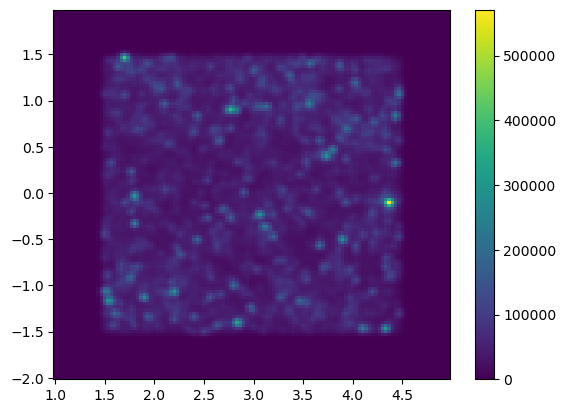

In [143]:
#%matplotlib widget

fig,ax = plt.subplots(1)

xaxis = (testmap.ra*u.deg / cosmo.arcsec_per_kpc_comoving(0.1)).to(u.Mpc).value
yaxis = (testmap.dec*u.deg / cosmo.arcsec_per_kpc_comoving(0.1)).to(u.Mpc).value

# ax.pcolormesh(xaxis, yaxis, np.nanmean(testmap.map, axis=0))
c = ax.pcolormesh(testmap.ra, testmap.dec, np.nanmean(testmap.map, axis=0))
fig.colorbar(c)

In [144]:
print(dir(testmap))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'copy', 'cosmic_volume_spacing', 'dec', 'decbe', 'dump', 'fieldcent', 'flims', 'freq', 'freqbe', 'fstep', 'info', 'load', 'load_cosmogrid', 'load_sim', 'map', 'mask_isolated_pix', 'match_wcs', 'ra', 'rabe', 'rebin_freq', 'rebin_freq_byfactor', 'rebin_space_byfactor', 'rms', 'setup_coordinates', 'subtract_mean', 'to_flux', 'to_linelum', 'type', 'unit', 'upgrade', 'x', 'xlims', 'xstep', 'y', 'ylims', 'ystep']


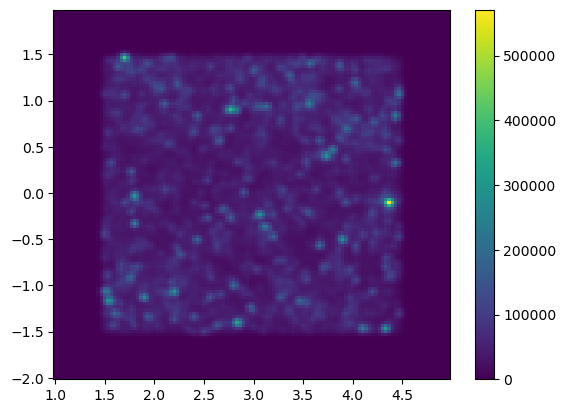

In [145]:
#%matplotlib widget

fig,ax = plt.subplots(1)

xaxis = (testmap.ra*u.deg / cosmo.arcsec_per_kpc_comoving(0.1)).to(u.Mpc).value
yaxis = (testmap.dec*u.deg / cosmo.arcsec_per_kpc_comoving(0.1)).to(u.Mpc).value

# ax.pcolormesh(xaxis, yaxis, np.nanmean(testmap.map, axis=0))
c = ax.pcolormesh(testmap.ra, testmap.dec, np.nanmean(testmap.map, axis=0))
# ax.imshow(testmap.ra*u.deg, testmap.freq, np.nanmean(testmap.map, axis=2).T)
# ax.imshow(np.nanmean(testmap.map, axis=2))

# ax.scatter(ca)
fig.colorbar(c)

In [146]:
(testmap.ra*u.deg / cosmo.arcsec_per_kpc_comoving(0.1)).to(u.Mpc)

<Quantity [ 7.31105912,  7.55476109,  7.79846306,  8.04216503,  8.285867  ,
            8.52956897,  8.77327094,  9.01697291,  9.26067488,  9.50437685,
            9.74807882,  9.99178079, 10.23548276, 10.47918473, 10.7228867 ,
           10.96658867, 11.21029064, 11.45399261, 11.69769458, 11.94139656,
           12.18509853, 12.4288005 , 12.67250247, 12.91620444, 13.15990641,
           13.40360838, 13.64731035, 13.89101232, 14.13471429, 14.37841626,
           14.62211823, 14.8658202 , 15.10952217, 15.35322414, 15.59692611,
           15.84062808, 16.08433005, 16.32803202, 16.571734  , 16.81543597,
           17.05913794, 17.30283991, 17.54654188, 17.79024385, 18.03394582,
           18.27764779, 18.52134976, 18.76505173, 19.0087537 , 19.25245567,
           19.49615764, 19.73985961, 19.98356158, 20.22726355, 20.47096552,
           20.71466749, 20.95836946, 21.20207144, 21.44577341, 21.68947538,
           21.93317735, 22.17687932, 22.42058129, 22.66428326, 22.90798523,
           2

In [147]:
with np.load(homedir+'mass_sims/mass_simsfiuducial_schechter_1_12345_mass_map.npz') as f:
    print(f.files)
    ra = f['map_pixel_ra']
    dec = f['map_pixel_dec']
    mapcube = f['map_cube']
    freq = f['map_frequencies']

['fov_x', 'fov_y', 'pix_size_x', 'pix_size_y', 'npix_x', 'npix_y', 'map_pixel_ra', 'map_pixel_dec', 'map_frequencies', 'map_cube', 'cat_cube', 'cat_hits', 'sigma']


In [148]:
mapcube.shape

(120, 120, 256)

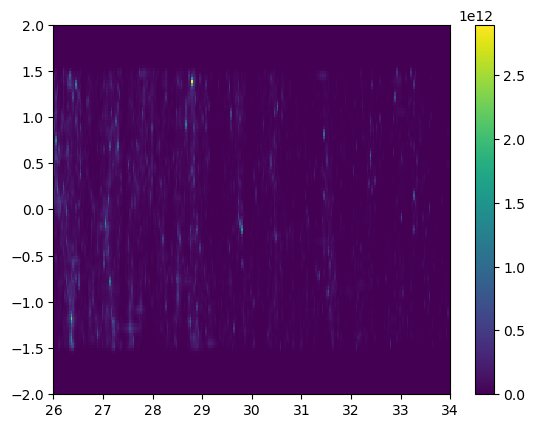

In [149]:
#%matplotlib widget

fig,ax = plt.subplots(1)

# ax.pcolormesh(ra, dec, np.nanmean(mapcube, axis=2))
c = ax.pcolormesh(freq, dec, np.nanmean(mapcube, axis=1))
fig.colorbar(c)

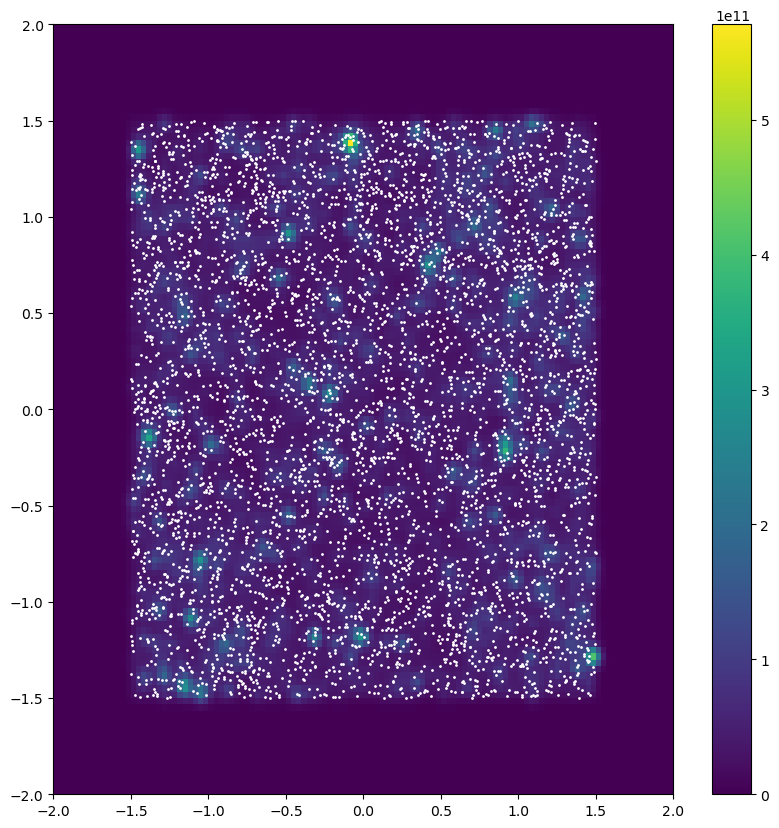

In [158]:
#%matplotlib ipynpl

fig,ax = plt.subplots(1, figsize=(10,10))

c = ax.pcolormesh(ra, dec, np.nanmean(mapcube, axis=2))
# c = ax.pcolormesh(freq, dec, np.nanmean(mapcube, axis=1))

ax.scatter(cat_ra, cat_dec, s=1, color='white')

fig.colorbar(c)

In [152]:
with np.load(homedir+'mass_sims/mass_simsfiuducial_schechter_1_12345_cat.npz') as f:
    print(f.files)
    cat_ra = f['ra']
    cat_dec = f['dec']

['dec', 'ra', 'z', 'Lco', 'Lcat', 'vhalo', 'M']


simulation setup (make sure you can load the lower-redshift sim, check what's hardcoded))

In [62]:
simpars = llm.SimParameters()
ppcat = homedir+'EXCLAIM_z0.1-1.0_seed_13579_subfield_0.npz'
halos = llm.HaloCatalog(simpars)
halos.load(ppcat, simpars)
minz, maxz = st.minmax(halos.redshift)
simpars.z_i = minz
simpars.z_f = 0.6 # set by desi BGS
simpars.nu_i = st.nuem_to_nuobs(simpars.nu_rest, simpars.z_i)
simpars.nu_f = st.nuem_to_nuobs(simpars.nu_rest, simpars.z_f)
simpars.mass_cutoff = 1e15
halos.cull(simpars)

	halo catalog contains:
		 ['cosmo_header', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'M', 'zhalo', 'zform']

	1437338 halos loaded
   0 sec

	411559 halos remain after mass/map cut
   0 sec


figure out the luminosity function itself (it's given in magnitudes)

In [63]:
xarr = np.linspace(-24, -10, num=200)

In [64]:
magcoeffs = [-20.97, 10**-2.06, -1.28, -10, -24]

In [65]:
def magschechter(M, coeffs):
    # to make this work you do have to flip the M-Mstar to Mstar-M in the reference paper
    [Mstar, phistar, alpha, Mmin, Mmax] = coeffs
    
    return np.log(10)/2.5 * phistar * np.power(10, 0.4*(1+alpha)*(Mstar-M)) * np.exp(-10**(0.4*(Mstar-M)))

In [66]:
np.exp(-0.0004)

np.float64(0.9996000799893344)

In [67]:
np.ptp(halos.ra)

np.float32(2.999978)

In [68]:
print(dir(halos))

['M', 'Omega_L', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'attrcut_subset', 'chi', 'copy', 'cosmo', 'cull', 'dec', 'get_velocities', 'indexcut', 'load', 'load_luminosities', 'masscut_subset', 'nhalo', 'ns', 'observation_cull', 'offset_velocities', 'ra', 'redshift', 'sigma8', 'vmaxcut_subset', 'vx', 'vy', 'vz', 'write_cat', 'x_pos', 'y_pos', 'z_pos', 'zformation']


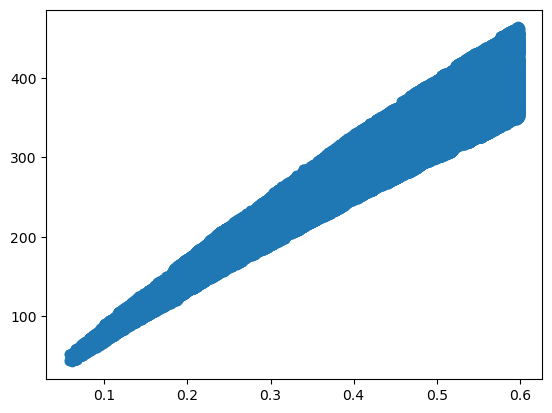

In [69]:
#%matplotlib widget

fig,ax = plt.subplots(1)

ax.scatter(halos.redshift, halos.x_pos)

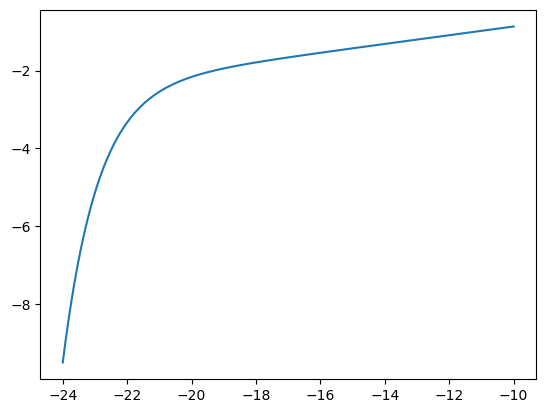

In [11]:
#%matplotlib widget

fig,ax = plt.subplots(1)

ax.plot(xarr, np.log10(magschechter(xarr, magcoeffs)))

# ax.plot(xarr, np.log10( np.log(10)/2.5 * 10**-2.14 * 10**(0.4*(1-1.39)*(xarr-(-20.43))) * np.exp(-10**(0.4*(xarr-(-20.43)))) ) )

In [12]:
testbgs,_ = llm.abundancematch_mags(magschechter, magcoeffs, halos, simpars)

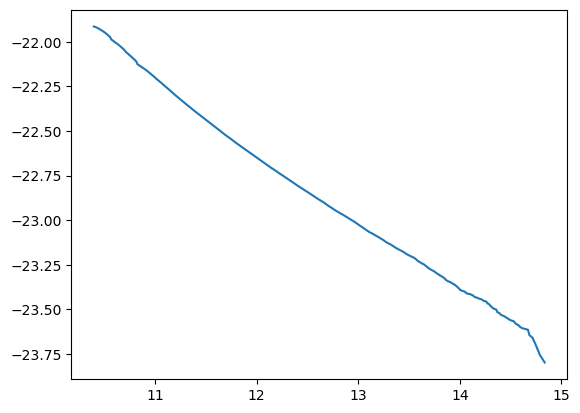

In [13]:
##%matplotlib widget

fig,ax = plt.subplots(1)

ax.plot(np.log10(halos.M), llm.Lsun_to_Mbol(testbgs))

# ax.plot(xarr, np.log10( np.log(10)/2.5 * 10**-2.14 * 10**(0.4*(1-1.39)*(xarr-(-20.43))) * np.exp(-10**(0.4*(xarr-(-20.43)))) ) )

In [14]:
dls = cosmo.luminosity_distance(halos.redshift)

In [15]:
ms = 5*np.log10(dls.value) + 25 + llm.Lsun_to_Mbol(testbgs)

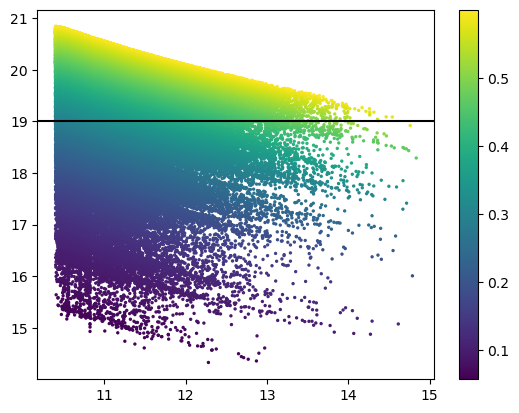

In [16]:
#%matplotlib widget

fig,ax = plt.subplots(1)

c = ax.scatter(np.log10(halos.M), ms, s=2, c=halos.redshift)
ax.axhline(19, color='k')
fig.colorbar(c)

# ax.plot(xarr, np.log10( np.log(10)/2.5 * 10**-2.14 * 10**(0.4*(1-1.39)*(xarr-(-20.43))) * np.exp(-10**(0.4*(xarr-(-20.43)))) ) )

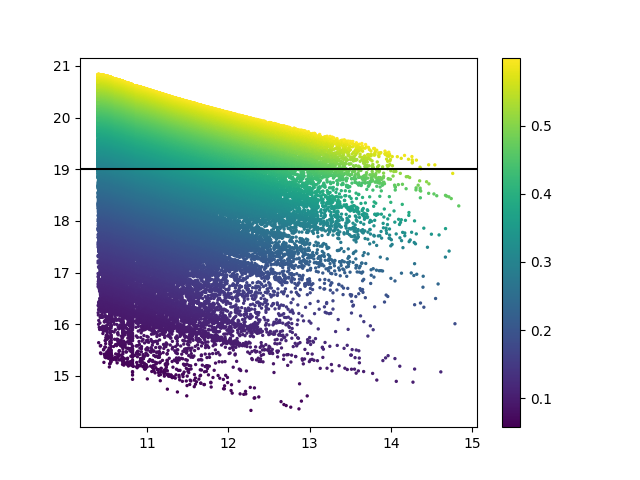

In [14]:
%matplotlib widget

fig,ax = plt.subplots(1)

c = ax.scatter(np.log10(halos.M), ms, s=2, c=halos.redshift)
ax.axhline(19, color='k')
fig.colorbar(c)

# ax.plot(xarr, np.log10( np.log(10)/2.5 * 10**-2.14 * 10**(0.4*(1-1.39)*(xarr-(-20.43))) * np.exp(-10**(0.4*(xarr-(-20.43)))) ) )

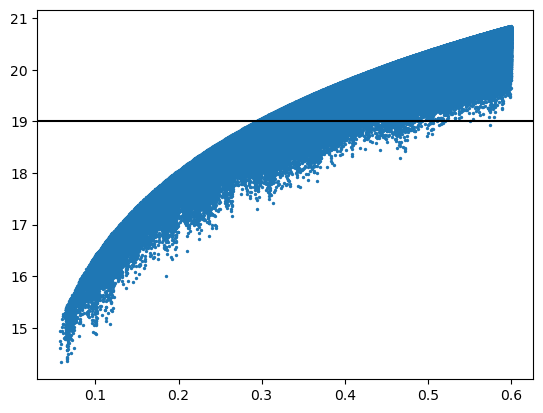

In [17]:
#%matplotlib widget

fig,ax = plt.subplots(1)

ax.scatter(halos.redshift, ms, s=2)
ax.axhline(19, color='k')

# ax.plot(xarr, np.log10( np.log(10)/2.5 * 10**-2.14 * 10**(0.4*(1-1.39)*(xarr-(-20.43))) * np.exp(-10**(0.4*(xarr-(-20.43)))) ) )

this seems halfway reasonable but i have absolutely nothing to test it against

# test out luminosity function

from https://arxiv.org/abs/2511.01803v1

## does stack lcat_cutoff work with magnitudes

yes? the way i set it up i think we're good

In [9]:
seed = 0
mapfiles = []
catfiles = []
mapfiles.append(f'/home/finneas/Documents/COMAP/Low Redshift search/mass_sims/bgs/fiuducial_schechter_{seed}_12345_mass_map.npz')
catfiles.append(np.sort(glob.glob(f'/home/finneas/Documents/COMAP/Low Redshift search/mass_sims/bgs/fiuducial_schechter_{seed}_*_cat.npz')))

# actual COMAP maps for masking purposes
s12stackmapfiles = ['/mn/stornext/d16/cmbco/comap/delaney/comap/data/s12_combined/latest/co2_s12_v5_take6_n5_subtr_exper.h5',
                '/mn/stornext/d16/cmbco/comap/delaney/comap/data/s12_combined/latest/co7_s12_v5_take6_n5_subtr_exper.h5',
                '/mn/stornext/d16/cmbco/comap/delaney/comap/data/s12_combined/latest/co6_s12_v5_take6_n5_subtr_exper.h5']



In [10]:
params = st.parameters()
params.xwidth = 5
params.ywidth = 5
params.chanwidth = 0.03125

mapinst, catinst = st.field_setup(mapfiles[0], catfiles[0][0], params, sim_cat=True,
                                  lcat_cutoff=19, goal_nobj=2000, weight='log')


	2000 halos remain after observability cuts
trimming catalog


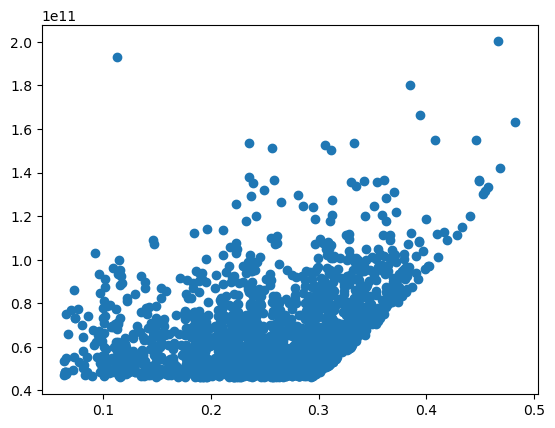

In [12]:
#%matplotlib widget

fig,ax = plt.subplots(1)

ax.scatter(catinst.z, catinst.Lcat)

# Testing BGS

In [21]:
params = llm.SimParameters()
params.catalog_model = 'schechter_mag'
params.catalog_coeffs = [0.849e43, 3.9e-4, -1.8, 39, 45]
params.catdex = 0.11
params.mass_cutoff = 1e15
filename = f'/home/finneas/Documents/COMAP/Low Redshift search/EXCLAIM_z0.1-1.0_seed_13579_subfield_0.npz'

halos = llm.HaloCatalog(params, filename)
llm.Mhalo_to_Ls(halos, params)

In [22]:
halos = llm.HaloCatalog(params, filename)
llm.Mhalo_to_Ls(halos, params)

	halo catalog contains:
		 ['cosmo_header', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'M', 'zhalo', 'zform']

	1437338 halos loaded
   1 sec

	0 halos remain after mass/map cut
   0 sec
   0 sec
done CO luminosities
   0 sec
done catalog luminosities
   0 sec


#### End of Testing

the eboss_LEDE function is defined ito magnitudes -- i think the current schechter would have to be rearranged to work with them. make a new schechter function ito magnitudes

test eboss_LEDE again as a cross-check to make sure i know what's going on

In [54]:
params = llm.SimParameters()
params.catalog_model = 'eboss'
params.catalog_coeffs = [-26.71, -5.93, -3.89, -1.47, -0.46, -0.06, -0.14, 0.32, 2.2, 2.62, -15, -29]
params.catdex = 0.11
filename = f'/mn/stornext/d16/cmbco/comap/delaney/joint_mocks/peakpatch_catalogs/COMAP_z2.39-3.44_1140Mpc_seed_13579.npz'

In [55]:
# set up catalog
halos = llm.HaloCatalog(params, filename)
# llm.Mhalo_to_Ls(halos, params)

	halo catalog contains:
		 ['cosmo_header', 'M', 'zform', 'vx', 'zhalo', 'vy', 'y', 'x', 'vz', 'z']

	51306419 halos loaded
   8 sec

	7133737 halos remain after mass/map cut
   2 sec


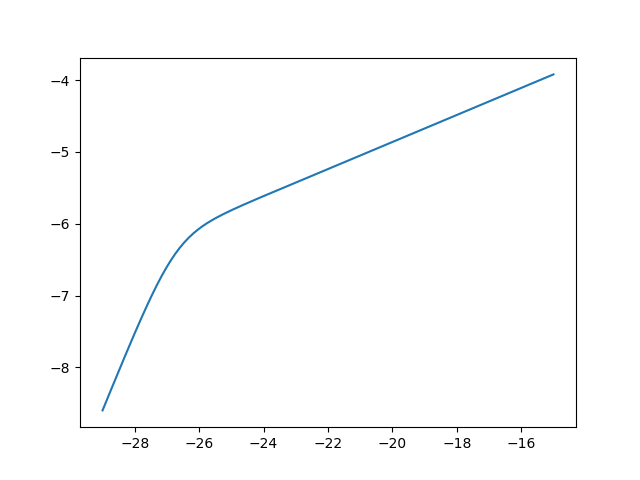

In [57]:
%matplotlib widget

fig,ax = plt.subplots(1)

xarr = np.linspace(params.catalog_coeffs[-2], params.catalog_coeffs[-1], num=200)

ax.plot(xarr, np.log10(llm.eboss_LEDE(xarr, params.catalog_coeffs)))

In [60]:
ebosslums,_ = llm.abundancematch_mags(llm.eboss_LEDE, params.catalog_coeffs, halos, params)

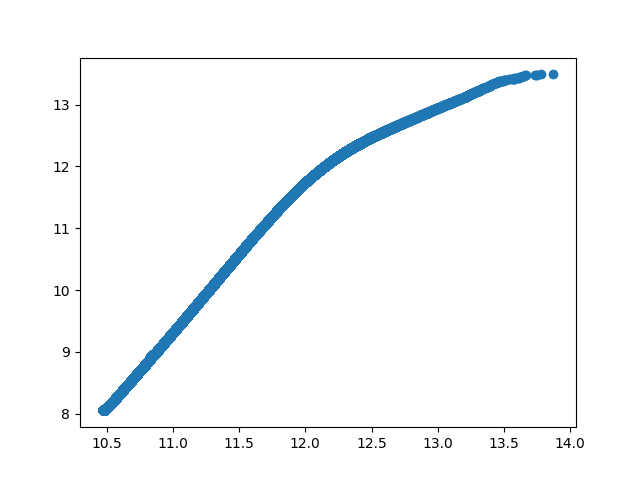

In [62]:
%matplotlib widget

fig,ax = plt.subplots(1)

ax.scatter(np.log10(halos.M), np.log10(ebosslums))

In [ ]:
simpars = llm.SimParameters()
minval = 37
maxval = 45
simpars.catalog_coeffs = [0.849e43, 3.9e-4, -1.8, minval, maxval]
simpars.lcat_cutoff = 892761886
simpars.catdex = 0.49
simpars.obs_weight = 'none'
simpars.goal_nobj = 5000

ppcat = 'peakpatch_catalogues/COMAP_z2.39-3.44_1140Mpc_seed_13585.npz'
halos = llm.HaloCatalog(simpars, ppcat)

# look at stack output

## LAEs

In [3]:
os.chdir(homedir+'stacks/axions/mass_measurements/mass_stacks/')

In [129]:
stackdirs = np.sort(glob.glob('laes/*_stack_full_x5f3_rot/data'))

In [130]:
params = st.parameters()
params.xwidth = 5
params.ywidth = 5
params.chanwidth = 0.03125

In [131]:
def linelum_to_flux(cube, params):
    
    # put into the appropriate astropy units
    cube.cube = cube.cube * u.K * u.km/u.s * u.pc**2
    cube.cuberms = cube.cuberms * u.K * u.km/u.s * u.pc**2
    
    freqbc = cube.nuobs_mean + cube.freqarr
    
    nuobs = np.tile(freqbc, (cube.cube.shape[2], cube.cube.shape[1], 1)).T * u.GHz
    
    # find redshift from nuobs
    zval = st.freq_to_z(params.centfreq * u.GHz, nuobs)
    
    # luminosity distance in mpc
    DLs = params.cosmo.luminosity_distance(zval)
    
    # velocity-integrated flux
    fluxdeltav = (cube.cube * (2*const.k_B/const.c**2) * (nuobs**2 * (1+zval)**3) / DLs**2).to(u.Jy*u.km/u.s)
    dfluxdeltav = (cube.cuberms * (2*const.k_B/const.c**2) * (nuobs**2 * (1+zval)**3) / DLs**2).to(u.Jy*u.km/u.s)
    
    cube.cube = fluxdeltav.value.astype('float64')
    cube.cuberms = dfluxdeltav.value.astype('float64')
    cube.unit = 'flux'
    
    return

In [132]:
def flux_to_T(cube, params):
    
    # put into the appropriate astropy units
    cube.cube = cube.cube * u.Jy * u.km/u.s
    cube.cuberms = cube.cuberms * u.Jy * u.km/u.s
    
    # central frequency of each individual spectral channel
    freqbc = cube.nuobs_mean + cube.freqarr
    fstep = freqbc[1] - freqbc[0]
    freqvals = np.tile(freqbc, (cube.cube.shape[2], cube.cube.shape[1], 1)).T * u.GHz
    
    # undo the velocity integration
    delnus = (fstep * u.GHz / freqvals * const.c).to(u.km / u.s)

    Snu = cube.cube / delnus
    dSnu = cube.cuberms / delnus
    
    # beam size
    pixsize = (cube.xarr[1] - cube.xarr[0]) * u.arcmin
    omega_B = (pixsize ** 2).to(u.sr)
    
    Tb = (Snu / omega_B.value * const.c**2 / (2*freqvals**2*const.k_B)).to(u.K)
    dTb = (dSnu / omega_B.value * const.c**2 / (2*freqvals**2*const.k_B)).to(u.K)
    
    # undo main beam correction
    Tb *= 0.72
    dTb *= 0.72
    
    cube.cube = Tb.value.astype('float64')
    cube.cuberms = dTb.value.astype('float64')
    cube.unit = 'K'
    
    return

In [133]:
cubelist = []
masslist = []
for idir in stackdirs:
    cube = st.cubelet(str(idir), params)
    linelum_to_flux(cube, params)
    flux_to_T(cube, params)
    cubelist.append(cube)
    
    masslist.append(cube.get_aperture()[0]*1e6)

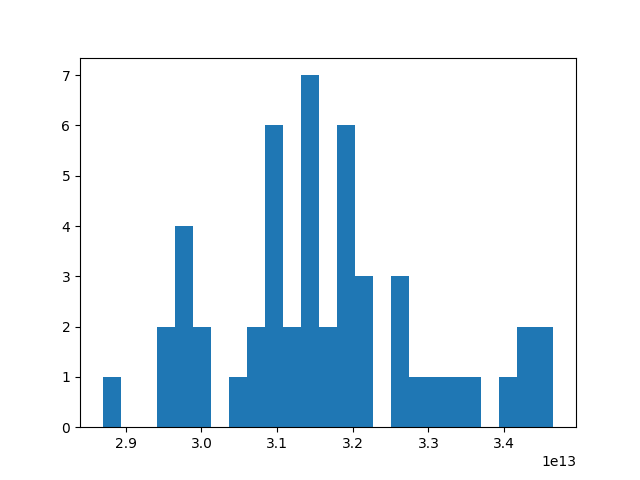

In [134]:
%matplotlib widget

fig,ax = plt.subplots(1)

ax.hist(np.array(masslist), bins=25);

In [135]:
print(f"{np.nanmean(masslist):.3e} pm {np.std(masslist):.3e}")

3.162e+13 pm 1.405e+12


## QSOs

In [136]:
stackdirs = np.sort(glob.glob('qsos/*_stack_full_x5f3_rot/data'))

In [137]:
cubelist = []
masslist = []
for idir in stackdirs:
    cube = st.cubelet(str(idir), params)
    linelum_to_flux(cube, params)
    flux_to_T(cube, params)
    cubelist.append(cube)
    
    masslist.append(cube.get_aperture()[0]*1e6)

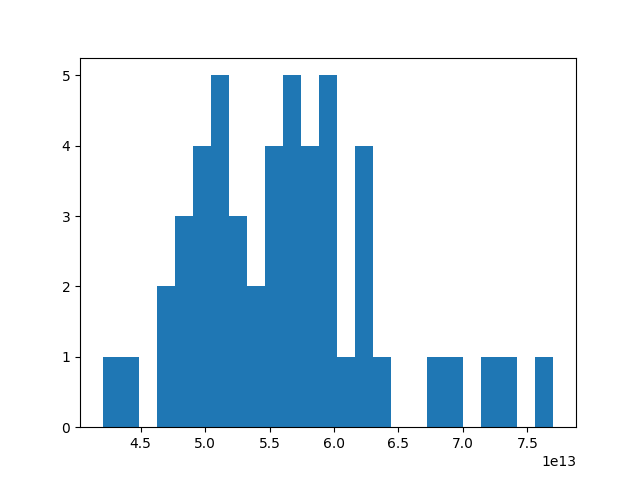

In [138]:
%matplotlib widget

fig,ax = plt.subplots(1)

ax.hist(np.array(masslist), bins=25);

In [139]:
print(f"{np.nanmean(masslist):.3e} pm {np.std(masslist):.3e}")

5.629e+13 pm 7.264e+12


figure out the luminosity function (given in magnitudes)

# messing around

## test getting the actual comap masks

In [94]:
s12stackmapfiles = ['/mn/stornext/d16/cmbco/comap/delaney/comap/data/s12_combined/latest/co2_s12_v5_take6_n5_subtr_exper.h5',
                    '/mn/stornext/d16/cmbco/comap/delaney/comap/data/s12_combined/latest/co7_s12_v5_take6_n5_subtr_exper.h5',
                    '/mn/stornext/d16/cmbco/comap/delaney/comap/data/s12_combined/latest/co6_s12_v5_take6_n5_subtr_exper.h5']

In [96]:
for file in s12stackmapfiles:
    with h5py.File(file) as f:
        tmap = np.array(f.get('map_coadd'))
        trms = np.array(f.get('sigma_wn_coadd'))

In [98]:
trms.shape

(4, 64, 120, 120)

In [99]:
mappars = st.parameters()
mappars.chanwidth = 0.03125

In [101]:
tmapinst = st.maps(mappars, inputfile=s12stackmapfiles[0])

scaling rms
masking isolated signal pixels


In [104]:
tmapinst.rms.shape

(256, 120, 120)

### make a tester sim because i think the axes are going to be flipped

In [106]:
ppfile = np.sort(glob.glob('/mn/stornext/d16/cmbco/comap/delaney/joint_mocks/peakpatch_catalogs/COMAP_z2.39-3.44_1140Mpc_seed_*.npz'))[0]

In [84]:
ppfile = np.sort(glob.glob('/home/finneas/Documents/COMAP/limlam_cats/COMAP_z2.39-3.44_1140Mpc_seed_13585.npz'))[0]

In [82]:
ppfile = np.sort(glob.glob('/home/finneas/Documents/COMAP/Low Redshift search/EXCLAIM_z0.1-1.0_seed_13579_subfield_1.npz'))[0]

In [87]:
# set up parameters that won't be changed
params = llm.SimParameters()
params.catalog_model = 'schechter'
params.catalog_coeffs = [0.849e43, 3.9e-4, -1.8, 39, 45] # default catalog

params.nmaps = 256
params.npix_x = 120
params.npix_y = 120
params.xrefine = 1
params.freqrefine = 1
params.lcat_cutoff = 892761886
params.add_comap_noise = False
params.rho = -0.5
params.velocity_attr = 'vmpeakincli'
params.co_model = 'fiuducial'
params.co_model_coeffs = [-2.85,-0.42,10.63,12.3,0.42]   
params.save_hits = False
params.beambroaden = True
params.goal_nobj = 8000

params.units = 'mass'

params.halo_catalog_file = ppfile

# do three different 'fields':
i = 0
nseed = 12345 + i

params.lum_uncert_seed = nseed

halos = llm.HaloCatalog(params, params.halo_catalog_file)

llm.Mhalo_to_Ls(halos, params)

outpath = 'tester'
params.output_dir = outpath 
sseed = params.halo_catalog_file.split('_')[-1][:-4]
seed = int(sseed)
        
mapinst = llm.SimMap(params)
mapinst.mockmapmaker(halos, params)

# filenames
outfile = outpath +'0.1-1.0_fiuducial_schechter_'+sseed+'_'+str(nseed)
params.map_output_file = outfile+'_mass_map.npz'
params.cat_output_file = outfile+'_cat.npz'

# mapinst.write(params)

halos.observation_cull(params)
# halos.write_cat(params)

	halo catalog contains:
		 ['cosmo_header', 'M', 'zform', 'vx', 'zhalo', 'vy', 'y', 'x', 'vz', 'z']

	51315889 halos loaded
   3 sec

	7089665 halos remain after mass/map cut
   1 sec
   0 sec
done CO luminosities
   1 sec
done catalog luminosities
   1 sec
   0 sec

	preserving halo masses

	subset 0 / 5 complete

	subset 1 / 5 complete

	subset 2 / 5 complete

	subset 3 / 5 complete

	subset 4 / 5 complete

smoothing by synthesized beam: 256 channels total

	 done 0 of 256 channels

	 done 100 of 256 channels

	 done 200 of 256 channels
(120, 120, 256)

	preserving halo masses

	Binning catalog halos into map

	4465875 halos remain after attribute cut

	8000 halos remain after observability cuts


In [113]:
print(dir(mapinst))

['Ompix', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'add_foreground', 'add_random_comap_noise', 'catmap', 'copy', 'dnu', 'fov_x', 'fov_y', 'from_file', 'map', 'mockmapmaker', 'nmaps', 'npix_x', 'npix_y', 'nu_bincents', 'nu_binedges', 'nu_f', 'nu_i', 'nu_rest', 'pix_bincents_x', 'pix_bincents_y', 'pix_binedges_x', 'pix_binedges_y', 'pix_size_x', 'pix_size_y', 'setup_empty', 'subtract_mean', 'totalcovol', 'voxcovol', 'write', 'z_f', 'z_i']


In [115]:
mapinst.map.shape

(120, 120, 256)

In [116]:
np.arange(13579, 13678, 2)

array([13579, 13581, 13583, 13585, 13587, 13589, 13591, 13593, 13595,
       13597, 13599, 13601, 13603, 13605, 13607, 13609, 13611, 13613,
       13615, 13617, 13619, 13621, 13623, 13625, 13627, 13629, 13631,
       13633, 13635, 13637, 13639, 13641, 13643, 13645, 13647, 13649,
       13651, 13653, 13655, 13657, 13659, 13661, 13663, 13665, 13667,
       13669, 13671, 13673, 13675, 13677])

In [ ]:
# flip frequency axis and rearrange so freq axis is the first in the map
        self.map = np.swapaxes(self.map, 0, -1)
        # self.map = np.swapaxes(self.map, 1, 2) #*******
        self.freq = np.flip(self.freq)
        self.map = np.flip(self.map, axis=0)

In [118]:
catfiles = []
for seed in np.arange(13579, 13678, 2):
    catfiles.append(np.sort(glob.glob(homedir+f'stacks/axions/mass_measurements/mass_sims/fiuducial_schechter_{seed}_*_cat.npz')))

In [120]:
catfiles[0]

array(['/mn/stornext/d16/cmbco/comap/delaney/stacks/axions/mass_measurements/mass_sims/fiuducial_schechter_13579_12345_cat.npz',
       '/mn/stornext/d16/cmbco/comap/delaney/stacks/axions/mass_measurements/mass_sims/fiuducial_schechter_13579_12346_cat.npz',
       '/mn/stornext/d16/cmbco/comap/delaney/stacks/axions/mass_measurements/mass_sims/fiuducial_schechter_13579_12347_cat.npz'],
      dtype='<U118')

In [126]:
# actual COMAP maps for masking purposes

# do this in the stack itself?
s12stackmapfiles = ['/mn/stornext/d16/cmbco/comap/delaney/comap/data/s12_combined/latest/co2_s12_v5_take6_n5_subtr_exper.h5',
                    '/mn/stornext/d16/cmbco/comap/delaney/comap/data/s12_combined/latest/co7_s12_v5_take6_n5_subtr_exper.h5',
                    '/mn/stornext/d16/cmbco/comap/delaney/comap/data/s12_combined/latest/co6_s12_v5_take6_n5_subtr_exper.h5']

mappars = st.parameters()
mappars.chanwidth = 0.03125

rmslist = []
for file in s12stackmapfiles:
    mapinst = st.maps(mappars, inputfile=file)

    # rmsarr = np.swapaxes(mapinst.map, 0, -1)
    # rmsarr = np.flip(rmsarr, axis=0)
    rmslist.append(mapinst.rms)

scaling rms
masking isolated signal pixels
scaling rms
masking isolated signal pixels
scaling rms
masking isolated signal pixels


/tmp/ipykernel_2963964/3545227851.py:5: RuntimeWarning: Mean of empty slice
  ax.pcolormesh(np.nanmean(rmslist[0], axis=0))


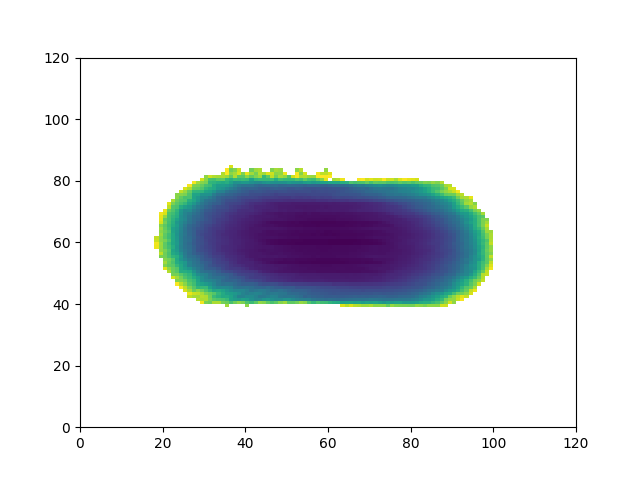

In [128]:
%matplotlib widget

fig,ax = plt.subplots(1)

ax.pcolormesh(np.nanmean(rmslist[0], axis=0))

stacks are doing a unit conversion that they really shouldn't be -- want pure mass units and we're getting those out converted into line luminosity

- figure out how to not do this conversion?

- starter: just undo the conversion

In [44]:
cube = st.cubelet(str(stackdirs[0]), params)

In [36]:
linelum = cube.cube * u.K * u.km/u.s * u.pc**2

In [80]:
fluxcube = cube.copy()

In [81]:
linelum_to_flux(fluxcube, params)

In [82]:
flux_to_T(fluxcube, params)

In [84]:
fluxcube.get_aperture()[0]*1e6

44208764328583.766

In [55]:
((2*const.k_B/const.c**2) * (nuobs**2 * (1+zval)**3) / DLs**2).to(u.Jy*u.km/u.s / (u.K*u.km/u.s*u.pc**2))

<Quantity [[[2.43278885e-12, 2.43278885e-12, 2.43278885e-12, ...,
             2.43278885e-12, 2.43278885e-12, 2.43278885e-12],
            [2.43278885e-12, 2.43278885e-12, 2.43278885e-12, ...,
             2.43278885e-12, 2.43278885e-12, 2.43278885e-12],
            [2.43278885e-12, 2.43278885e-12, 2.43278885e-12, ...,
             2.43278885e-12, 2.43278885e-12, 2.43278885e-12],
            ...,
            [2.43278885e-12, 2.43278885e-12, 2.43278885e-12, ...,
             2.43278885e-12, 2.43278885e-12, 2.43278885e-12],
            [2.43278885e-12, 2.43278885e-12, 2.43278885e-12, ...,
             2.43278885e-12, 2.43278885e-12, 2.43278885e-12],
            [2.43278885e-12, 2.43278885e-12, 2.43278885e-12, ...,
             2.43278885e-12, 2.43278885e-12, 2.43278885e-12]],

           [[2.43865925e-12, 2.43865925e-12, 2.43865925e-12, ...,
             2.43865925e-12, 2.43865925e-12, 2.43865925e-12],
            [2.43865925e-12, 2.43865925e-12, 2.43865925e-12, ...,
             2.4386

In [9]:
freqbc = cube.nuobs_mean + cube.freqarr

nuobs = np.tile(freqbc, (cube.cube.shape[2], cube.cube.shape[1], 1)).T * u.GHz

# find redshift from nuobs:
zval = st.freq_to_z(params.centfreq * u.GHz, nuobs)  # *****************

# luminosity distance in Mpc
DLs = params.cosmo.luminosity_distance(zval)

In [10]:
fluxdv = (linelum * (nuobs ** 2 * (1 + zval) ** 3) / DLs**2 * (2*const.k_B) / const.c**2).to(u.Jy*u.km/u.s)

In [11]:
# central frequency of each individual spectral channel
freqbc = cube.nuobs_mean + cube.freqarr
fstep = freqbc[1] - freqbc[0]
freqvals = np.tile(freqbc, (cube.cube.shape[2], cube.cube.shape[1], 1)).T * u.GHz
delnus = (fstep * u.GHz / freqvals * const.c).to(u.km / u.s)

pixsize = (cube.xarr[1] - cube.xarr[0]) * u.arcmin
omega_B = (pixsize ** 2).to(u.sr)

In [12]:
flux = fluxdv/delnus

In [13]:
Tb = (flux / omega_B.value * const.c**2 / (2*freqvals**2*const.k_B)).to(u.K)

In [14]:
testcube = cube.copy()

In [15]:
testcube.cube = fluxdv.value

In [56]:
testcube.get_aperture()[0]

92846693988.94728

In [31]:
print(dir(params))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'adaptivephotometry', 'beamwidth', 'bootstrapseed', 'centfreq', 'chanmeanfilter', 'chanwidth', 'copy', 'cosmo', 'cosmogrid', 'create_sensmap_bootstrap', 'cubelet', 'cubesavepath', 'datasavepath', 'dir', 'fitmasknbeams', 'fitmeanlimit', 'fitnbeams', 'freqmaskwidth', 'freqstackwidth', 'frequsewidth', 'freqwidth', 'gauss_kernel', 'goalnumcutouts', 'info', 'isolatedpixcutoff', 'isolatedpixkernel', 'lowmodefilter', 'make_output_pathnames', 'maskisolatedpix', 'nthreads', 'obsunits', 'parallelize', 'physicalspace', 'plotcubelet', 'plotfreq', 'plotsavepath', 'plotspace', 'plotunits', 'returncutlist', 'rmsscale', 'rng', 'rotate', 'rotseed', 'savedata', 'sa

In [33]:
params.plotunits

'linelum'

# look at the sim output? units are kinda wonky

In [17]:
mapfiles = np.sort(glob.glob(homedir+'stacks/axions/mass_measurements/mass_sims/*_mass_map.npz'))

In [19]:
with np.load(mapfiles[0]) as f:
    print(f.files)
    
    tmap = f['map_cube']

['fov_x', 'fov_y', 'pix_size_x', 'pix_size_y', 'npix_x', 'npix_y', 'map_pixel_ra', 'map_pixel_dec', 'map_frequencies', 'map_cube', 'cat_cube', 'cat_hits', 'sigma']


In [27]:
f"{np.nanmean(tmap)*25*3:.3e}"

'1.685e+13'

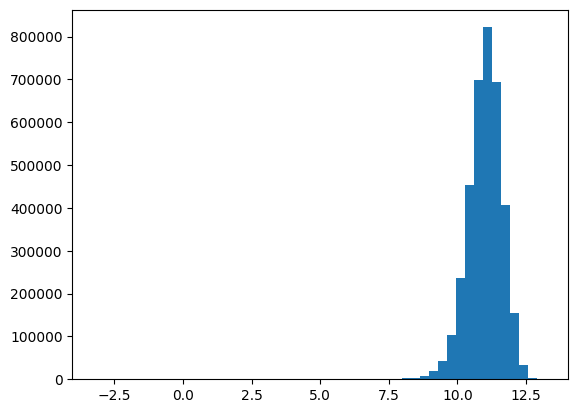

In [23]:
%matplotlib inline

fig,ax = plt.subplots(1)

ax.hist(np.log10(tmap.flatten()), bins=50);

# test generating sims

In [18]:
ppfiles = np.sort(glob.glob('/home/finneas/Documents/COMAP/limlam_cats/COMAP_z2.39-3.44_1140Mpc_seed_13585.npz'))

In [104]:
ppfiles = np.sort(glob.glob('/home/finneas/Documents/COMAP/Low Redshift search/EXCLAIM_z0.1-1.0_seed_13579_subfield_1.npz'))

In [105]:
len(ppfiles)

1

In [106]:
nseed = 12345

In [126]:
# set up parameters that won't be changed
params = llm.SimParameters()
params.catalog_model = 'schechter'
params.catalog_coeffs = [0.849e43, 3.9e-4, -1.8, 39, 45] # default catalog

params.nmaps = 256 # ** going for high angular resolution, no refinement for binning pre-injection, and lower spectral resolution
params.npix_x = 120
params.npix_y = 120
params.xrefine = 1
params.freqrefine = 1
params.lcat_cutoff = 892761886
params.add_comap_noise = False
params.rho = -0.5
params.velocity_attr = 'vmpeakincli'
params.co_model = 'fiuducial'
params.co_model_coeffs = [-2.85,-0.42,10.63,12.3,0.42]   
params.save_hits = False
params.beambroaden = True
params.goal_nobj = 5000
#params.sim_cat = True;
params.units = 'mass'
params.min_mass = 1
params.mass_cutoff = 1000000000000000000000000
params.z_i = 0.1;
params.z_f = 1.0;
params.nu_rest = 40;

params.halo_catalog_file = ppfiles[0]
params.lum_uncert_seed = nseed

In [129]:
vars(params)

{'param': None,
 'f': '/home/finneas/.local/share/jupyter/runtime/kernel-5d9ffcdf-296c-4232-9a24-5714b93ed710.json',
 'verbose': True,
 'halo_catalog_file': np.str_('/home/finneas/Documents/COMAP/Low Redshift search/EXCLAIM_z0.1-1.0_seed_13579_subfield_1.npz'),
 'mass_cutoff': 1000000000000000000000000,
 'min_mass': 1,
 'model': 'fiuducial',
 'co_model_coeffs': [-2.85, -0.42, 10.63, 12.3, 0.42],
 'catalog_model': 'schechter',
 'catalog_coeffs': [8.49e+42, 0.00039, -1.8, 39, 45],
 'catdex': 0.41,
 'codex': 0.42,
 'rho': -0.5,
 'lum_uncert_seed': 12345,
 'save_scatterless_lums': True,
 'cosmology': 'comap',
 'units': 'mass',
 'nmaps': 256,
 'npix_x': 120,
 'npix_y': 120,
 'fov_x': 4.0,
 'fov_y': 4.0,
 'nu_f': 26.0,
 'nu_i': 34.0,
 'nu_rest': 40,
 'xrefine': 1,
 'freqrefine': 1,
 'save_hits': False,
 'weight_hits': False,
 'beambroaden': True,
 'beamkernel': None,
 'beamfwhm': 4.5,
 'freqbroaden': True,
 'bincount': 5,
 'fwhmfunction': None,
 'velocity_attr': 'vmpeakincli',
 'add_comap_no

In [131]:
halos = llm.HaloCatalog(params, params.halo_catalog_file)

llm.Mhalo_to_Ls(halos, params)

	halo catalog contains:
		 ['cosmo_header', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'M', 'zhalo', 'zform']

	1386719 halos loaded
   0 sec

	289694 halos remain after mass/map cut
   0 sec
   0 sec
done CO luminosities
   0 sec
done catalog luminosities
   0 sec


In [132]:
# generate og map
mapinst = llm.SimMap(params)
mapinst.mockmapmaker(halos, params)

   0 sec

	preserving halo masses

	subset 0 / 5 complete

	subset 1 / 5 complete

	subset 2 / 5 complete

	subset 3 / 5 complete

	subset 4 / 5 complete

smoothing by synthesized beam: 256 channels total

	 done 0 of 256 channels

	 done 100 of 256 channels

	 done 200 of 256 channels
(120, 120, 256)

	preserving halo masses

	Binning catalog halos into map


In [133]:
outpath = homedir+'mass_sims'

In [134]:
params.output_dir = outpath 
sseed = params.halo_catalog_file.split('_')[-1][:-4]
seed = int(sseed)

In [135]:
# filenames
outfile = outpath +'fiuducial_schechter_'+sseed+'_'+str(nseed)
params.map_output_file = outfile+'_mass_map.npz'
params.cat_output_file = outfile+'_cat.npz'

In [136]:
mapinst.write(params)

halos.observation_cull(params)
halos.write_cat(params)


	Saving Map Data Cube to
		 /home/finneas/Documents/COMAP/Low Redshift search/mass_simsfiuducial_schechter_1_12345_mass_map.npz
saving catalog!!
   0 sec

	192743 halos remain after attribute cut

	5000 halos remain after observability cuts

	Saving Halo catalog to
		 /home/finneas/Documents/COMAP/Low Redshift search/mass_simsfiuducial_schechter_1_12345_cat.npz


In [32]:
print(dir(halos))

['Lcat', 'Lco', 'M', 'Omega_L', 'Tcat', 'Tco', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'attrcut_subset', 'chi', 'copy', 'cosmo', 'cov', 'cull', 'dec', 'get_velocities', 'indexcut', 'load', 'load_luminosities', 'masscut_subset', 'nhalo', 'ns', 'nu', 'nucat', 'observation_cull', 'offset_velocities', 'ra', 'redshift', 'scatterless_Lcat', 'scatterless_Lco', 'sigma8', 'sin_i', 'vbroaden', 'vmaxcut_subset', 'vx', 'vy', 'vz', 'write_cat', 'x_pos', 'y_pos', 'z_pos', 'zcat', 'zformation']


In [33]:
print(dir(mapinst))

['Ompix', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'add_foreground', 'add_random_comap_noise', 'catmap', 'copy', 'dnu', 'fov_x', 'fov_y', 'from_file', 'map', 'mockmapmaker', 'nmaps', 'npix_x', 'npix_y', 'nu_bincents', 'nu_binedges', 'nu_f', 'nu_i', 'nu_rest', 'pix_bincents_x', 'pix_bincents_y', 'pix_binedges_x', 'pix_binedges_y', 'pix_size_x', 'pix_size_y', 'setup_empty', 'subtract_mean', 'totalcovol', 'voxcovol', 'write', 'z_f', 'z_i']


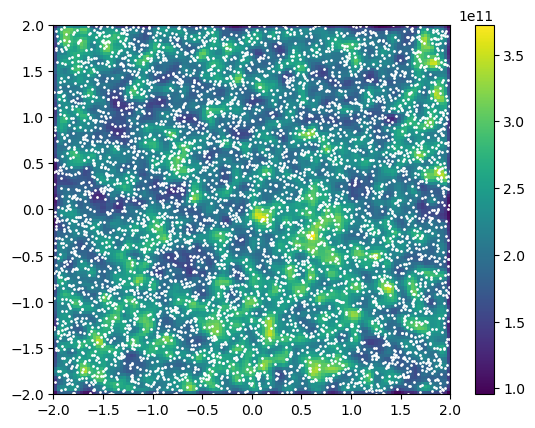

In [34]:
#%matplotlib inline

fig,ax = plt.subplots(1)

c = ax.pcolormesh(mapinst.pix_binedges_x, mapinst.pix_binedges_y,
                  np.nanmean(mapinst.map, axis=2))

ax.scatter(halos.ra, halos.dec, s=1, color='white')
fig.colorbar(c)

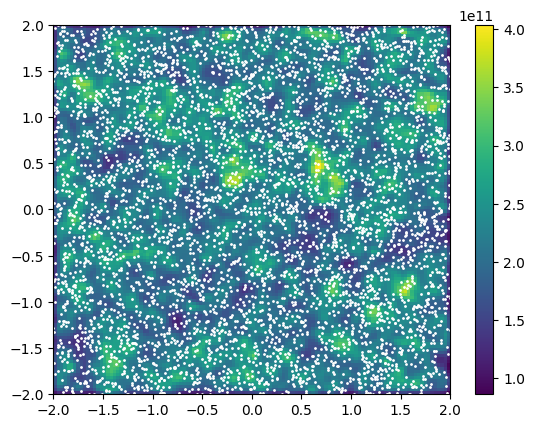

In [57]:
%matplotlib inline

fig,ax = plt.subplots(1)

c = ax.pcolormesh(mapinst.pix_binedges_x, mapinst.pix_binedges_y,
                  np.nanmean(mapinst.map, axis=2))

ax.scatter(halos.ra, halos.dec, s=1, color='white')
fig.colorbar(c)

In [ ]:
%matplotlib inline

fig,ax = pl

# BGS Test

In [4]:
import os
import sys
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from astropy.io import fits
import csv
from scipy.integrate import quad
import scipy.interpolate as interp
from scipy.optimize import curve_fit

from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import astropy.constants as const
from astropy.coordinates import SkyCoord
from astropy.table import Table, unique, join

cosmo = FlatLambdaCDM(H0=70*u.km / (u.Mpc*u.s), Om0=0.286, Ob0=0.047)

# funky plot packages
from astropy.convolution import convolve, Gaussian2DKernel, Tophat2DKernel
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import SymLogNorm
import matplotlib as mpl

sys.path.insert(0, '/home/finneas/Documents/COMAP/joint_limlam_mocker')

import limlam_mocker as llm

from multiprocessing import Pool

In [3]:

def magschechter(M, coeffs):
    # to make this work you do have to flip the M-Mstar to Mstar-M in the reference paper
    [Mstar, phistar, alpha, Mmin, Mmax] = coeffs
    
    return np.log(10)/2.5 * phistar * np.power(10, 0.4*(1+alpha)*(Mstar-M)) * np.exp(-10**(0.4*(Mstar-M)))

def generator(ppfile):
    
    # set up parameters that won't be changed
    params = llm.SimParameters()
    params.catalog_model = 'schechter'
    params.catalog_coeffs = [-20.97, 10**-2.06, -1.28, -10, -24]

    params.nmaps = 256
    params.npix_x = 120
    params.npix_y = 120
    params.xrefine = 1
    params.freqrefine = 1
    params.lcat_cutoff = 19
    params.add_comap_noise = False
    params.save_hits = False
    params.beambroaden = True
    params.goal_nobj = 15000 # probably going to be about 1000 objects?

    params.units = 'mass'

    params.halo_catalog_file = ppfile
    
    # do three different 'fields':
    for i in range(3):
        nseed = 12345 + i
        
        params.lum_uncert_seed = nseed

        halos = llm.HaloCatalog(params)
        halos.load(ppfile, params)
        minz, maxz = np.nanmin(halos.redshift), 0.6
        params.z_i = minz
        params.z_f = maxz
        params.nu_i = params.nu_rest / (1+params.z_i)
        params.nu_f = params.nu_rest / (1+params.z_f)
        params.mass_cutoff = 1e15
        halos.cull(params)

        testbgs,_ = llm.abundancematch_mags(magschechter, params.catalog_coeffs, halos, params)
        halos.Lcat = testbgs
        dls = cosmo.luminosity_distance(halos.redshift)
        ms = 5*np.log10(dls.value) + 25 + llm.Lsun_to_Mbol(testbgs)

        params.output_dir = outpath 
        sseed = params.halo_catalog_file.split('_')[-1][:-4]
        seed = int(sseed)
        
        if i == 0:
            mapinst = llm.SimMap(params)
            mapinst.mockmapmaker(halos, params)

        # filenames
        outfile = outpath +'fiuducial_schechter_'+sseed+'_'+str(nseed)
        params.map_output_file = outfile+'_mass_map.npz'
        params.cat_output_file = outfile+'_cat.npz'

        if i == 0:
            mapinst.write(params)

        halos.indexcut(np.where(ms < 19), in_place=True)
        rng = np.random.default_rng()
        keepidx = rng.choice(halos.nhalo, params.goal_nobj, replace=False)
        halos.indexcut(keepidx, in_place=True)
        halos.Lco = np.ones(len(halos.Lcat))
        halos.write_cat(params)


In [4]:
homedir = '/home/finneas/Documents/COMAP/Low Redshift search/'

ppfiles = np.sort(glob.glob(homedir+'EXCLAIM_z0.1-1.0_seed_13579_subfield_*.npz'))
outpath = homedir+'mass_sims/bgs/'

p = Pool(processes=10)
p.map(generator, ppfiles)

	halo catalog contains:
			halo catalog contains:
		  ['cosmo_header', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'M', 'zhalo', 'zform']['cosmo_header', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'M', 'zhalo', 'zform']


	1386719 halos loaded
  
	1437338 halos loaded 
0    sec0
 sec

	399817 halos remain after mass/map cut

	411559 halos remain after mass/map cut
      00  secsec

   0 sec
   0 sec

	preserving halo masses

	preserving halo masses

	subset 0 / 5 complete

	subset 0 / 5 complete

	subset 1 / 5 complete

	subset 1 / 5 complete

	subset 2 / 5 complete

	subset 2 / 5 complete

	subset 3 / 5 complete

	subset 3 / 5 complete

	subset 4 / 5 complete

smoothing by synthesized beam: 256 channels total

	subset 4 / 5 complete
	 done 0 of 256 channels


smoothing by synthesized beam: 256 channels total

	 done 0 of 256 channels

	 done 100 of 256 channels

	 done 100 of 256 channels

	 done 200 of 256 channels

	 done 200 of 256 channels
(120, 120, 256)(120, 120, 256)


	preserving halo masses
	pres

[None, None]

In [29]:
params = llm.SimParameters()
params.catalog_model = 'schechter_mag'
params.catalog_coeffs = [0.849e43, 3.9e-4, -1.8, 39, 45]
params.catdex = 0.11
filename = f'/home/finneas/Documents/COMAP/Low Redshift search/EXCLAIM_z0.1-1.0_seed_13579_subfield_1.npz'

params.nmaps = 256
params.npix_x = 120
params.npix_y = 120
params.xrefine = 1
params.freqrefine = 1
params.lcat_cutoff = 19
params.add_comap_noise = False
params.save_hits = False
params.beambroaden = True
params.mass_cutoff = 1000000000000000000000000
params.goal_nobj = 15000 # probably going to be about 1000 objects?

params.units = 'mass'



In [63]:
minz, maxz = np.nanmin(halos.redshift), 0.6
params.z_i = minz
params.z_f = maxz
params.nu_i = params.nu_rest / (1+params.z_i)
params.nu_f = params.nu_rest / (1+params.z_f)

halos = llm.HaloCatalog(params, filename)

llm.Mhalo_to_Ls(halos, params)

	halo catalog contains:
		 ['cosmo_header', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'M', 'zhalo', 'zform']

	1386719 halos loaded
   0 sec

	399817 halos remain after mass/map cut
   1 sec
   0 sec
done CO luminosities
   0 sec
done catalog luminosities
   0 sec


In [31]:
    halos = llm.HaloCatalog(params)
    halos.load(filename, params)
    minz, maxz = np.nanmin(halos.redshift), 0.6
    params.z_i = minz
    params.z_f = maxz
    params.nu_i = params.nu_rest / (1+params.z_i)
    params.nu_f = params.nu_rest / (1+params.z_f)
    params.mass_cutoff = 1e15
    halos.cull(params)

	halo catalog contains:
		 ['cosmo_header', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'M', 'zhalo', 'zform']

	1386719 halos loaded
   1 sec

	399817 halos remain after mass/map cut
   0 sec


In [37]:
halos.Lcat, params = llm.Mhalo_to_Lcatalog(halos, params)
mapinst = llm.SimMap(params)

outfile = '/home/finneas/Documents/COMAP/Low Redshift search/' +'fiuducial_schechter_mags'
params.map_output_file = outfile+'_mass_map.npz'
params.cat_output_file = outfile+'_cat.npz'

mapinst.mockmapmaker(halos, params)

mapinst.write(params)

   0 sec
   0 sec

	preserving halo masses

	subset 0 / 5 complete

	subset 1 / 5 complete

	subset 2 / 5 complete

	subset 3 / 5 complete

	subset 4 / 5 complete

smoothing by synthesized beam: 256 channels total

	 done 0 of 256 channels

	 done 100 of 256 channels

	 done 200 of 256 channels
(120, 120, 256)

	preserving halo masses

	Binning catalog halos into map

	Saving Map Data Cube to
		 /home/finneas/Documents/COMAP/Low Redshift search/fiuducial_schechter_mags_mass_map.npz
saving catalog!!
   0 sec


In [41]:
dls = cosmo.luminosity_distance(halos.redshift)
ms = 5*np.log10(dls.value) + 25 + llm.Lsun_to_Mbol(halos.Lcat)

halos.indexcut(np.where(ms < 19), in_place=True)
rng = np.random.default_rng()
keepidx = rng.choice(halos.nhalo, params.goal_nobj, replace=False)
halos.indexcut(keepidx, in_place=True)
halos.Lco = np.ones(len(halos.Lcat))
halos.write_cat(params)


	Saving Halo catalog to
		 /home/finneas/Documents/COMAP/Low Redshift search/fiuducial_schechter_mags_cat.npz


In [47]:
with np.load('/home/finneas/Documents/COMAP/Low Redshift search/fiuducial_schechter_mags_cat.npz') as f:
    print(f.files)
    cat_ra = f['ra']
    cat_dec = f['dec']

['dec', 'ra', 'z', 'Lco', 'Lcat', 'vhalo', 'M']


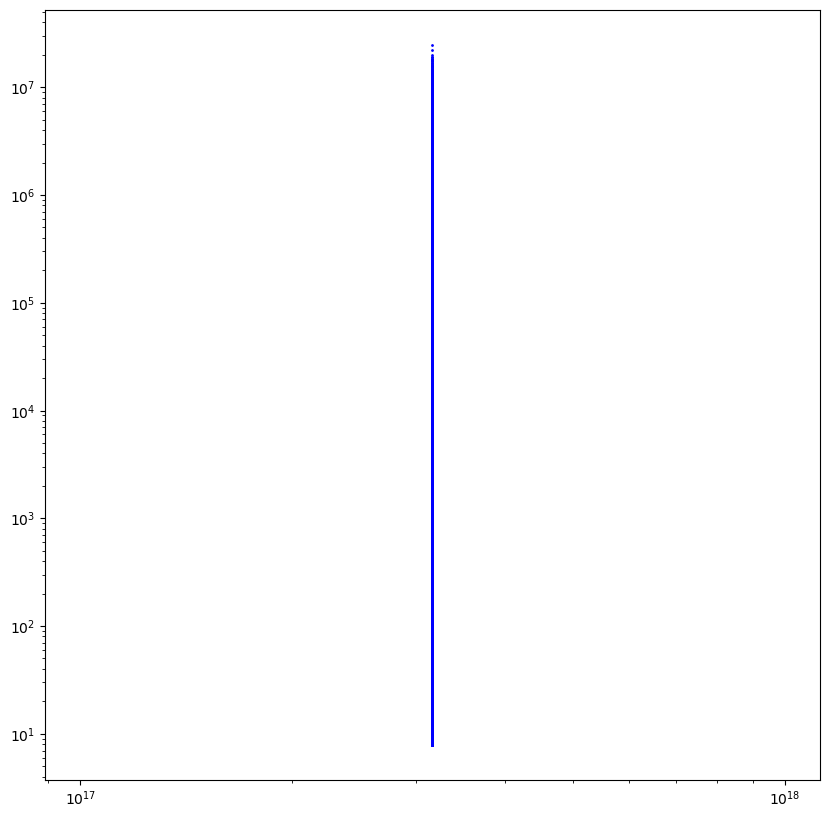

In [68]:
fig,ax = plt.subplots(1, figsize = (10,10))

#c = ax.pcolormesh(mapinst.pix_binedges_x, mapinst.pix_binedges_y,
#                  np.nanmean(mapinst.map, axis=2))
ax.loglog()
ax.scatter(halos.scatterless_Lcat, halos.scatterless_Lco, s=1, color='blue',)

In [52]:
# set up parameters that won't be changed
ppsim = '/home/finneas/Documents/COMAP/Low Redshift search/EXCLAIM_z0.1-1.0_seed_13579_subfield_1.npz'

params = llm.SimParameters()
params.catalog_model = 'schechter_mag'
params.catalog_coeffs = [0.849e43, 3.9e-4, -1.8, 39, 45] # Hetedex values

params.nmaps = 256 # ** going for high angular resolution, no refinement for binning pre-injection, and lower spectral resolution
params.npix_x = 120
params.npix_y = 120
params.xrefine = 1
params.freqrefine = 1

params.lcat_cutoff = 8260913427
params.add_comap_noise = False
params.rho = -0.5
params.velocity_attr = 'vmpeakincli'
params.co_model = 'fiuducial'
params.co_model_coeffs = [-2.85,-0.42,10.63,12.3,0.42]   
params.save_hits = False
params.beambroaden = True
params.mass_cutoff = 1000000000000000000000000
params.units = 'mass'

params.halo_catalog_file = ppsim
params.lum_uncert_seed = 12345

In [53]:
halos = llm.HaloCatalog(params, params.halo_catalog_file)
llm.Mhalo_to_Ls(halos, params)

	halo catalog contains:
		 ['cosmo_header', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'M', 'zhalo', 'zform']

	1386719 halos loaded
   0 sec

	0 halos remain after mass/map cut
   0 sec
   0 sec
done CO luminosities
   0 sec
done catalog luminosities
   0 sec


In [64]:
halos.Lcat

array([1.18685838e+17, 8.81021664e+16, 1.32325670e+17, ...,
       1.13942329e+17, 8.46296646e+16, 7.75269194e+17], shape=(399817,))